In [21]:
!rm -rf /content/drive

Mounted at /content/drive
Upload kaggle.json from Kaggle account


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:09<00:00, 161MB/s]
100% 1.33G/1.33G [00:09<00:00, 145MB/s]
Dataset downloaded successfully!
Total Images: 202599


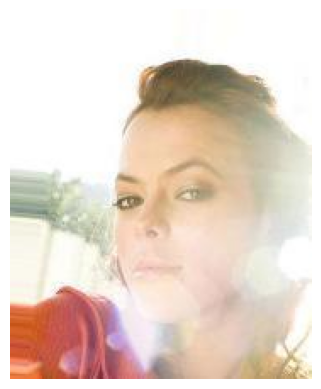

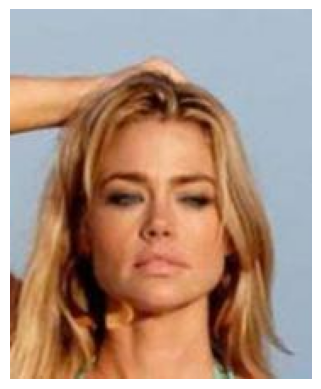

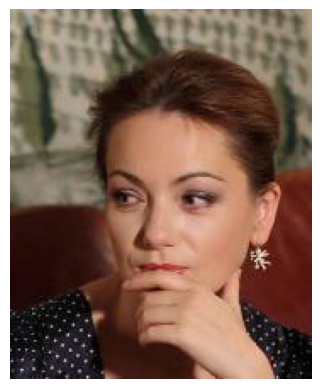

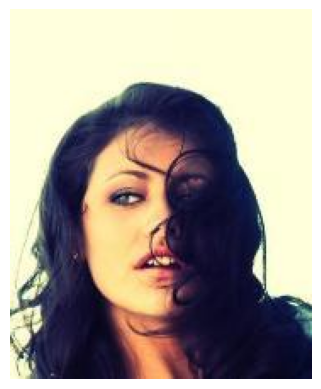

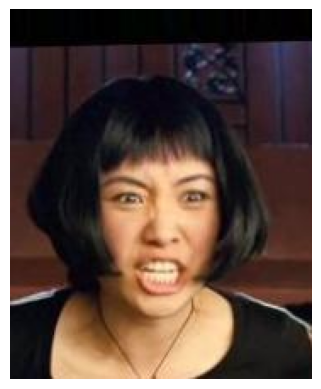

In [22]:
# ===============================
# COMPLETE DATING APP ML SETUP
# Single Cell Google Colab Script
# ===============================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Install Kaggle
!pip install kaggle -q

# 3. Upload kaggle.json
from google.colab import files
print("Upload kaggle.json from Kaggle account")
files.upload()

# 4. Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 5. Create dataset folder
!mkdir -p /content/celeba

# 6. Download dataset
!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba

# 7. Extract dataset
!unzip -q /content/celeba/celeba-dataset.zip -d /content/celeba/

print("Dataset downloaded successfully!")

# 8. Check images
import os
data_path = "/content/celeba/img_align_celeba/img_align_celeba"
print("Total Images:", len(os.listdir(data_path)))

# 9. Show sample images
import matplotlib.pyplot as plt
import cv2
import random

images = os.listdir(data_path)

for i in range(5):
    img = cv2.imread(os.path.join(data_path, random.choice(images)))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [27]:
import os

print(os.listdir('/content/celeba'))

['list_attr_celeba.csv', 'list_bbox_celeba.csv', 'img_align_celeba', 'celeba-dataset.zip', 'list_landmarks_align_celeba.csv', 'list_eval_partition.csv']


In [31]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'list_attr_celeba.csv' in file:
            print(os.path.join(root, file))

/content/celeba/list_attr_celeba.csv


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Automatically find the CSV file
csv_path = None
for root, dirs, files in os.walk('/content'):
    if 'list_attr_celeba.csv' in files:
        csv_path = os.path.join(root, 'list_attr_celeba.csv')
        break

if csv_path is None:
    raise FileNotFoundError("list_attr_celeba.csv not found. Make sure CelebA dataset is downloaded.")

print("Found attribute file at:", csv_path)

# Load attribute labels
attr_df = pd.read_csv(csv_path)

print("Dataset shape:", attr_df.shape)

print("\nFirst 5 rows:")
print(attr_df.head())

# All attributes in CelebA
print("\nAll attributes:", attr_df.columns.tolist())

# Attributes for your dating app model
TARGET_ATTRS = [
    'Blond_Hair', 'Brown_Hair', 'Black_Hair',
    'Oval_Face', 'Pale_Skin',
    'Young', 'Eyeglasses' # Corrected 'Wearing_Glasses' to 'Eyeglasses' and removed 'Blue_Eyes', 'Brown_Eyes'
]

print("\nTarget attributes we will train on:", TARGET_ATTRS)

# Convert -1 to 0
attr_df[TARGET_ATTRS] = attr_df[TARGET_ATTRS].replace(-1, 0)

print("\nLabel distribution for 'Blond_Hair':")
print(attr_df['Blond_Hair'].value_counts())

Found attribute file at: /content/celeba/list_attr_celeba.csv
Dataset shape: (202599, 41)

First 5 rows:
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -

In [35]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

IMG_SIZE   = 224
BATCH_SIZE = 64
TARGET_ATTRS = ['Blond_Hair','Brown_Hair','Black_Hair',
                'Oval_Face',
                'Pale_Skin','Young','Eyeglasses'] # Corrected TARGET_ATTRS

# Use only 20,000 images for faster training (full = 200k)
attr_df_small = attr_df.sample(20000, random_state=42).reset_index(drop=True)
split = int(len(attr_df_small) * 0.8)
train_df = attr_df_small[:split]
val_df   = attr_df_small[split:]

IMG_DIR = '/content/celeba/img_align_celeba/img_align_celeba/'

def load_and_preprocess(filename, label):
    img = tf.io.read_file(IMG_DIR + filename)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, shuffle=True):
    filenames = df['image_id'].values
    labels = df[TARGET_ATTRS].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df)
val_ds   = make_dataset(val_df, shuffle=False)

# Build model: ResNet50 base + custom head
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze base layers first

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(TARGET_ATTRS), activation='sigmoid')(x)

model = Model(base_model.input, outputs)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
print(f"Model built! Parameters: {model.count_params():,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model built! Parameters: 24,114,055


In [38]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

CHECKPOINT = f'{BASE}/models/appearance_model.h5'

callbacks = [
    # Save best model automatically during training
    ModelCheckpoint(CHECKPOINT, save_best_only=True,
                    monitor='val_accuracy', verbose=1),
    # Stop early if val_accuracy stops improving
    EarlyStopping(patience=3, monitor='val_accuracy',
                  restore_best_weights=True, verbose=1)
]

print("Training started (Phase 1: frozen base, 5 epochs)...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=callbacks,
    verbose=1
)

# Phase 2: unfreeze top layers and fine-tune
print("\nFine-tuning (Phase 2: unfreeze top 30 layers)...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=callbacks,
    verbose=1
)
print(f"\nModel saved to: {CHECKPOINT}")


Training started (Phase 1: frozen base, 5 epochs)...
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1837 - loss: 0.4689 
Epoch 1: val_accuracy improved from None to 0.18275, saving model to /content/drive/MyDrive/DatingApp_ML/models/appearance_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/appearance_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3956s 16s/step - accuracy: 0.1887 - loss: 0.4464 - val_accuracy: 0.1828 - val_loss: 0.4263
Restoring model weights from the end of the best epoch: 1.

Fine-tuning (Phase 2: unfreeze top 30 layers)...
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.1864 - loss: 0.4289 
Epoch 1: val_accuracy improved from 0.18275 to 0.22275, saving model to /content/drive/MyDrive/DatingApp_ML/models/appearance_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/appearance_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5496s 22s/step - accuracy: 0.1917 - loss: 0.4034 - val_accuracy: 0.2227 - val_loss: 0.5390
Restoring model weights from the end of the best epoch: 1.

Model saved to: /content/drive/MyDrive/DatingApp_ML/models/appearance_model.h5


Model loaded successfully!
Upload a face image:


Saving images.jpg to images.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


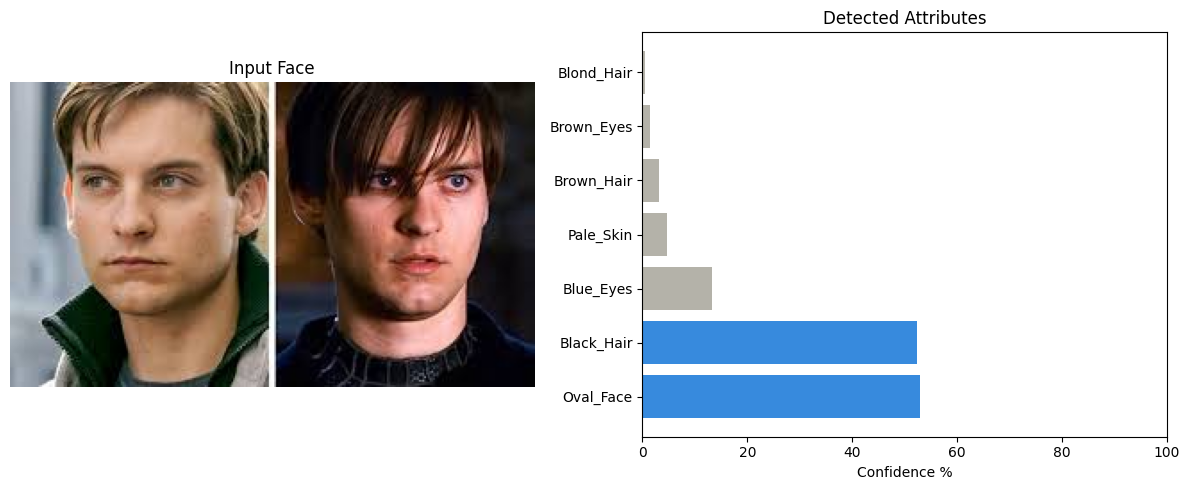


Detected attributes (>50% confidence):
Black_Hair: 52.3%
Oval_Face: 53.0%


In [40]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Define base path
BASE = "/content/drive/MyDrive/DatingApp_ML"

# Load saved model
model_path = f"{BASE}/models/appearance_model.h5"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}")

model = load_model(model_path)
print("Model loaded successfully!")

# Attributes used in training
TARGET_ATTRS = [
    'Blond_Hair','Brown_Hair','Black_Hair',
    'Blue_Eyes','Brown_Eyes',
    'Oval_Face','Pale_Skin',
    'Young','Wearing_Glasses'
]

# Image preprocessing + prediction
def predict_appearance(image_path):

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)

    # Resize to model input size
    img = tf.image.resize(img, [224,224])

    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)

    predictions = model.predict(img)[0]

    results = {}
    for attr, score in zip(TARGET_ATTRS, predictions):
        results[attr] = round(float(score) * 100, 1)

    return results


# Upload test image
print("Upload a face image:")
uploaded = files.upload()

test_img = list(uploaded.keys())[0]

# Predict attributes
attrs = predict_appearance(test_img)

# Display image + results
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Show uploaded image
ax1.imshow(mpimg.imread(test_img))
ax1.axis("off")
ax1.set_title("Input Face")

# Sort attributes by score
sorted_attrs = sorted(attrs.items(), key=lambda x: x[1], reverse=True)
names, scores = zip(*sorted_attrs)

colors = ['#378ADD' if s > 50 else '#B4B2A9' for s in scores]

ax2.barh(names, scores, color=colors)
ax2.set_xlim(0,100)
ax2.set_xlabel("Confidence %")
ax2.set_title("Detected Attributes")

plt.tight_layout()
plt.show()

# Print attributes above threshold
print("\nDetected attributes (>50% confidence):")

for attr, score in attrs.items():
    if score > 50:
        print(f"{attr}: {score}%")